# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

# NOx

# No lag vs 20Min Apriori models
### All inputs vs control inputs

In [1]:
import importlib
import functions  # First import
importlib.reload(functions)  # Reloads the module to reflect changes
from functions import *  # Now import updated functions

In [2]:
# #add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

In [ ]:
total_filter = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co.pkl')
df_merged = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/df_merged.pkl')
df_filtered_quantile = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/filtered_quantile.pkl')
total_filter_nox_sp = pd.read_pickle("/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_nox_del_25.pkl")
total_filter_co2_sp = pd.read_pickle("/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co2_del_149.pkl")
nox_20min_past_PP = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/nox_20min_past_PP.pkl')

In [4]:
total = ['NOx content in the raw gas (preheater outlet)',
'Exit temperature from each preheater cyclone (Stage 1A)',
'Exit temperature from each preheater cyclone (Stage 1B)',
'Exit temperature from each preheater cyclone (Stage 2)',
'Exit temperature from each preheater cyclone (Stage 3)',
'Exit temperature from each preheater cyclone (Stage 4)',
'Preheater gas outlet temperature',
'O2 content in the raw gas (preheater outlet)',
'Raw meal temperature (to preheater)',
'Raw meal mass flow rate (to preheater)',
'I Air (including transport air)', 'III Air flow rate',
'Solids outlet temperature (kiln inlet)', 'Fuel consumption (calciner)',
'Share of total fuel consumption',
'O2 content in the kiln gas (to preheater) at kiln inlet chamber',
'Hot meal temperature of lowest cyclone', 'Fuel consumption (kiln)',
'Total cooling air', 'III Air temperature (cooler outlet)',
'Clinker production',
'Total flow rate of gas entering the gas conditioning tower (GCT)',
'Temperature of gas entering the GCT', 'Spray water used in GCT',
'GCT outlet temperature', 'Temperature of gas entering the main fan',
'Total fan el. consumption', 'Rotational speed of each fan',
'Driver of rotary kiln', 'Raw mill el. Consumption',
'kiln inlet pressure', 'pre-calciner outlet pressure',
'pressure at the exit of each cyclone (Stage 1A)',
'pressure at the exit of each cyclone (Stage 1B)',
'pressure at the exit of each cyclone (Stage 2)',
'pressure at the exit of each cyclone (Stage 3)',
'pressure at the exit of each cyclone (Stage 4)',
'pressure at the exit of each cyclone  (Stage 5)',
'exit of conditioning tower ID fan inlet pressure',
'raw mill fan inlet pressure (Point 1)',
'raw mill fan inlet pressure (Point 2)']

control = ['NOx content in the raw gas (preheater outlet)',

'Raw meal temperature (to preheater)', 
'Raw meal mass flow rate (to preheater)',

'Fuel consumption (calciner)',
'Fuel consumption (kiln)',
# 'Share of total fuel consumption', # not relevant
'Driver of rotary kiln', # it is power consumption, +vely corelated

# 'O2 content in the kiln gas (to preheater) at kiln inlet chamber',
'I Air (including transport air)',
'Total cooling air',
'III Air flow rate',
'III Air temperature (cooler outlet)',
'kiln inlet pressure',
'Rotational speed of each fan'  # in %
]

Vcementos_common = ['NOx content in the raw gas (preheater outlet)',
       'Raw meal mass flow rate (to preheater)',
       'Fuel consumption (calciner)',
        'Fuel consumption (kiln)',    
       'III Air temperature (cooler outlet)',
       'Clinker outlet temperature']

# case study

# A. All inputs

A1. All inputs (20 min apriori)

In [ ]:
np.random.seed(1002)
random.seed(0)
ALL = nox_20min_past_PP.copy(deep = True)
ALL = ALL[total]
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] > 0) & (ALL['NOx content in the raw gas (preheater outlet)'] < 1000)]
X= ALL.iloc[:,1:]  # -6 for no timeseries, -1 for timeseries
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]
y = y2

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
model_nox = XGBRegressor(
subsample=0.9,           # Increase to allow each tree to utilize more samples
reg_lambda=1,            # Reduce L2 regularization to lessen constraints
reg_alpha=0,             # Remove L1 regularization to allow more flexibility
n_estimators=1500,       # Increase the number of boosting rounds
min_child_weight=1,      # Decrease to allow smaller leaf nodes
max_depth=12,            # Increase to enable learning more complex patterns
learning_rate=0.005,     # Decrease to ensure more gradual learning
colsample_bytree=0.9,    # Increase to allow each tree to use more features
random_state=42,         # Ensure reproducibility
tree_method='gpu_hist',  # Utilize GPU acceleration for faster computation
n_jobs=-1                # Use all available CPU cores



).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

A2. All inputs (no time lag)

Training 0.88 14.23 4.51
Test 0.79 18.65 5.92


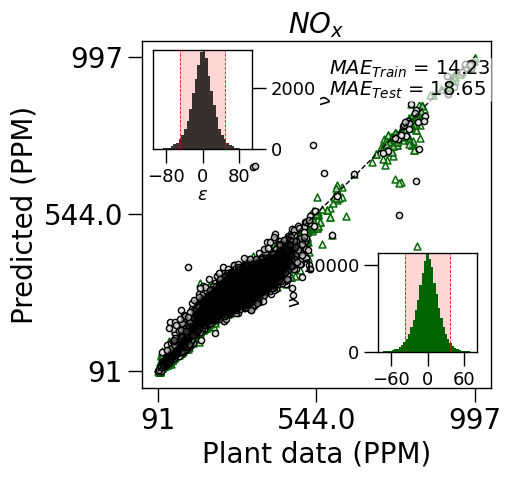

In [44]:
ALL = total_filter_nox_sp.copy(deep = True)  # Index = no_mising 
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] > 0) & (ALL['NOx content in the raw gas (preheater outlet)'] < 1000)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]

np.random.seed(1002)
random.seed(0)
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)


model_nox = XGBRegressor(
   subsample=0.85,
    reg_lambda=5,  # Reduced for less restriction
    reg_alpha=3,
    n_estimators=1200,  # Slightly increased
    min_child_weight=6,  # Reverted to original
    max_depth=8,  # Back to original
    learning_rate=0.03,  # Keeping same for stable updates
    colsample_bytree=0.75,  # Back to original
    random_state=42,
    tree_method='gpu_hist',
    n_jobs=-1# Helps deep trees grow efficiently

).fit(X_train,y_train)

parity(model_nox,X_train, y_train,X_test, y_test, y, 'PPM','$NO_{x}$','XGBoost')

# B. Control Inputs

B1. control (20 min apriori)

Training 0.88 14.13 4.5
Test 0.75 19.94 6.36


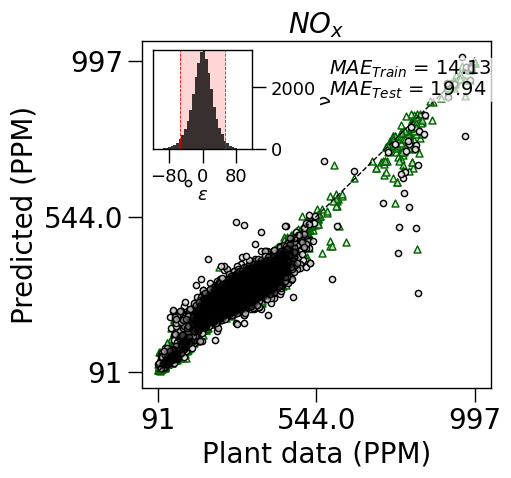

In [ ]:
np.random.seed(1002)
random.seed(0)
ALL = nox_20min_past_PP.copy(deep = True)
ALL = ALL[control]
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] > 0) & (ALL['NOx content in the raw gas (preheater outlet)'] < 1000)]
X= ALL.iloc[:,1:]  # -6 for no timeseries, -1 for timeseries
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]
y = y2
np.random.seed(1002)
random.seed(0)
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
model_nox = XGBRegressor(
    
subsample = 0.9,  
reg_lambda = 0.1,  
reg_alpha = 0.1,  
n_estimators = 1450,  
min_child_weight = 5,  
max_depth = 9,  # further inc overfit
learning_rate = 0.025,  
colsample_bytree = 0.8,  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1, 
).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

B2. control inputs (no timelag)

Total filter (high error deleted)

Training 0.87 14.65 4.67
Test 0.75 20.11 6.42


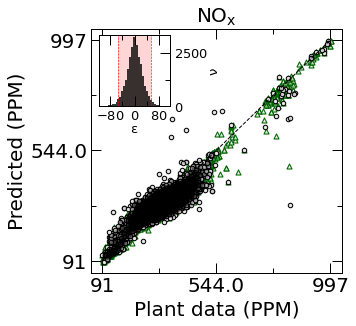

In [ ]:
# nox
np.random.seed(1002)
random.seed(0)
ALL = total_filter_nox_sp.copy(deep = True)
ALL = ALL[control]
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] > 0) & (ALL['NOx content in the raw gas (preheater outlet)'] < 1000)]
X= ALL.iloc[:,1:]  # -6 for no timeseries, -1 for timeseries
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]

y = y2
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
model_nox = XGBRegressor(

# 
subsample = 0.9,  
reg_lambda = 3,  
reg_alpha = 2.5,  
n_estimators = 1450,  
min_child_weight = 5,  
max_depth = 9,  # further inc overfit
learning_rate = 0.025,  
colsample_bytree = 0.8,  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1, 

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

Total filter (high error not deleted)

Training 0.82 17.52 5.6
Test 0.61 26.03 8.32


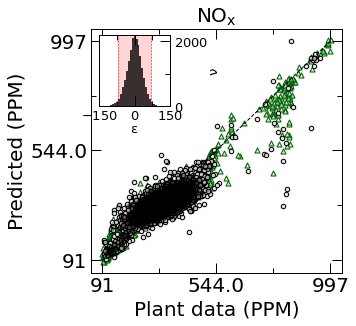

In [13]:
# nox
np.random.seed(1002)
random.seed(0)
ALL = total_filter.copy(deep = True)
ALL = ALL[control]
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] > 0) & (ALL['NOx content in the raw gas (preheater outlet)'] < 1000)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]

y = y2
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
model_nox = XGBRegressor(

# 
subsample = 0.9,  
reg_lambda = 3,  
reg_alpha = 2.5,  
n_estimators = 1450,  
min_child_weight = 5,  
max_depth = 9,  # further inc overfit
learning_rate = 0.025,  
colsample_bytree = 0.8,  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1, 

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

Control model [Quantile filter]

Different hyper parameters trial:

In [5]:
np.random.seed(1002)
random.seed(0)
ALL = df_filtered_quantile.copy(deep = True)
ALL = ALL[control]
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] >= 90) & (ALL['NOx content in the raw gas (preheater outlet)'] <= 1000)]
X= ALL.iloc[:,1:]  # -6 for no timeseries, -1 for timeseries
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]

y = y2
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

Training 0.76 21.64 7.0
Test 0.65 26.14 8.48


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, cursive
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


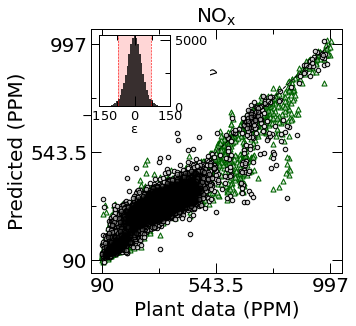

In [ ]:
np.random.seed(1002)
random.seed(0)
ALL = df_filtered_quantile.copy(deep = True)
ALL = ALL[control]
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] >= 90) & (ALL['NOx content in the raw gas (preheater outlet)'] <= 1000)]
X= ALL.iloc[:,1:]  # -6 for no timeseries, -1 for timeseries
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]

y = y2
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

model_nox = XGBRegressor(

subsample = 0.9,  
reg_lambda = 3,  
reg_alpha = 2.5,  
n_estimators = 1450,  
min_child_weight = 5,  
max_depth = 9,  # further inc overfit
learning_rate = 0.025,  
colsample_bytree = 0.8,  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1, 

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

Training 0.93 11.65 3.76
Test 0.7 24.01 7.76


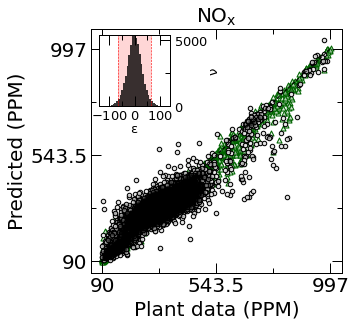

In [ ]:
model_nox = XGBRegressor(

subsample = 0.9,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 1,  # Increased to add slight regularization  
reg_alpha = 1,  # Reduced to allow more flexibility in feature selection  
n_estimators = 1700,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 6,  # Increased to prevent too complex splits  
max_depth = 12,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.025,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

Training 0.99 3.38 1.09
Test 0.73 22.83 7.37


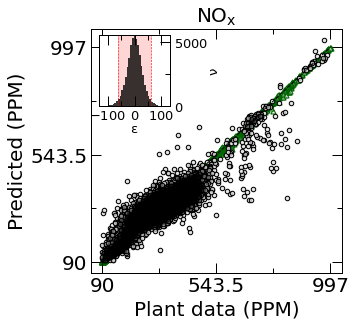

In [ ]:
model_nox = XGBRegressor(

subsample = 0.9,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 1,  # Increased to add slight regularization  
reg_alpha = 1,  # Reduced to allow more flexibility in feature selection  
n_estimators = 1750,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 4,  # Increased to prevent too complex splits  
max_depth = 13,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.025,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

Training 0.96 8.96 2.89
Test 0.71 23.57 7.61


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, cursive
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


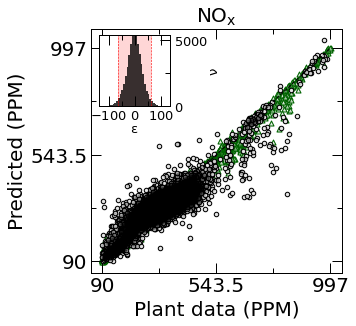

In [7]:
model_nox = XGBRegressor(

subsample = 0.9,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 1,  # Increased to add slight regularization  
reg_alpha = 1,  # Reduced to allow more flexibility in feature selection  
n_estimators = 1700,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 6,  # Increased to prevent too complex splits  
max_depth = 13,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.025,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

Training 0.91 13.07 4.22
Test 0.7 23.94 7.74


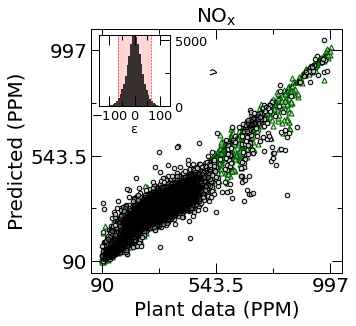

In [11]:
model_nox = XGBRegressor(

subsample = 0.7,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 2,  # Increased to add slight regularization  
reg_alpha = 2,  # Reduced to allow more flexibility in feature selection  
n_estimators = 2000,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 8,  # Increased to prevent too complex splits  
max_depth = 13,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.015,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

#......................................................Best generalizable model..........................

Training 0.92 12.46 4.01
Test 0.76 21.88 7.06


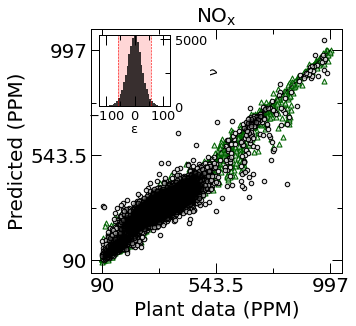

In [18]:
model_nox = XGBRegressor(

subsample = 0.7,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 2,  # Increased to add slight regularization  
reg_alpha = 2,  # Reduced to allow more flexibility in feature selection  
n_estimators = 2500,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 9,  # Increased to prevent too complex splits  
max_depth = 13,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.010,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

#......................................................Best Ovefit model (used for study)..........................

Training 0.94 10.3 3.31
Test 0.77 21.28 6.86


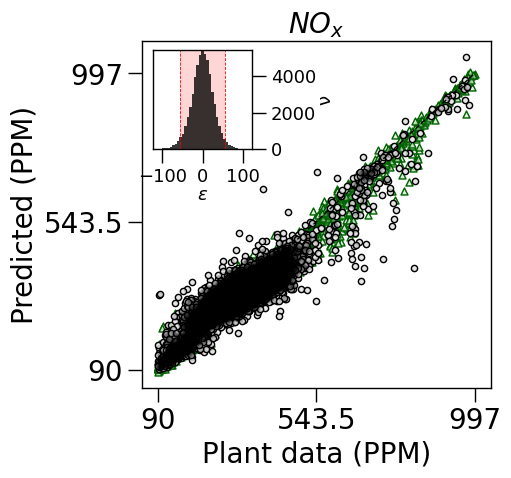

In [ ]:
model_nox = XGBRegressor(
subsample = 0.7,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 2,  # Increased to add slight regularization  
reg_alpha = 2,  # Reduced to allow more flexibility in feature selection  
n_estimators = 2500,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 9,  # Increased to prevent too complex splits  
max_depth = 14,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.010,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')
with open(f'/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/all_models_train/general_models/nox/NOX_control_overfit.pkl', 'wb') as f:   # save best model
    pickle.dump(model_nox,f)

# best regressor from RandomSearchCV

Training 1.0 2.64 0.85
Test 0.8 19.54 6.28


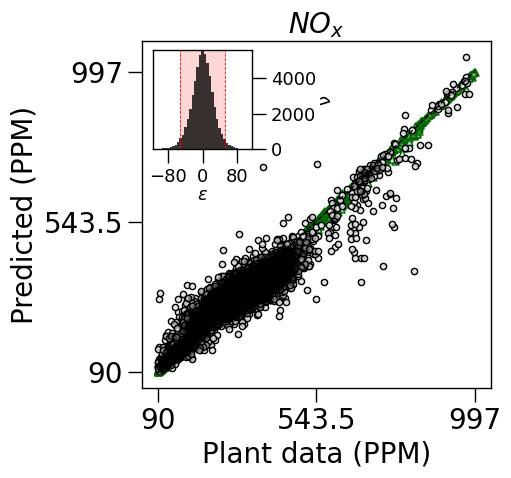

In [5]:
# best regressor from randomsearchCV
control_nox_model = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_models/general_models/Control/control_nox_bst_regressor.pkl', 'rb'))
parity(control_nox_model,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

# Best regressor Optuna

Training 1.0 1.88 0.61
Test 0.8 19.36 6.23


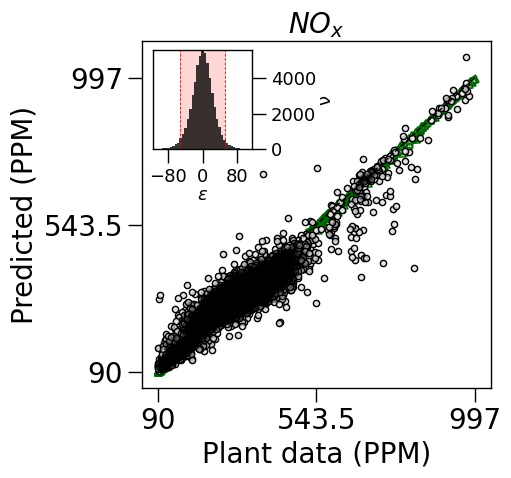

In [ ]:
# Cell walltime 11 min
model_nox = XGBRegressor(
subsample = 0.7,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 1,  # Increased to add slight regularization  
reg_alpha = 5,  # Reduced to allow more flexibility in feature selection  
n_estimators = 3000,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 7,  # Increased to prevent too complex splits  
max_depth = 16,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.015,  # Lowered for more stable updates  
colsample_bytree = 0.9,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')
# with open(f'/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/all_models_train/general_models/nox/NOX_control_overfit.pkl', 'wb') as f:   # save best model
#     pickle.dump(model_nox,f)

In [ ]:
control_nox_model = pickle.load(open('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/all_models_train/general_models/nox/NOX_control_overfit.pkl', 'rb'))

Training 0.91 12.83 4.14
Test 0.71 23.78 7.69


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, cursive
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


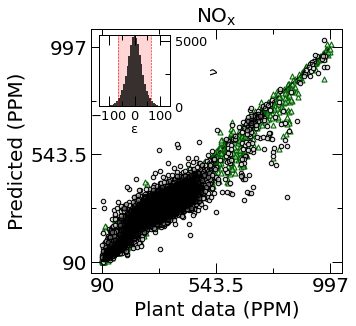

In [ ]:
model_nox = XGBRegressor(

subsample = 0.7,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 2,  # Increased to add slight regularization  
reg_alpha = 2,  # Reduced to allow more flexibility in feature selection  
n_estimators = 2500,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 9,  # Increased to prevent too complex splits  
max_depth = 14,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.010,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')
# with open(f'/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/all_models_train/general_models/nox/NOX_control_overfit.pkl', 'wb') as f:   # save best model
#     pickle.dump(model_nox,f)

#### Transfer model for Vcementos

Training 0.88 15.29 4.95
Test 0.69 24.35 7.87


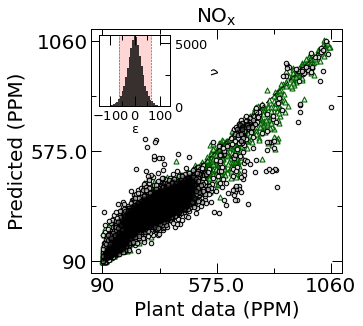

In [ ]:
np.random.seed(1002)
random.seed(0)
ALL = df_filtered_quantile.copy(deep = True)
ALL = ALL[Vcementos_common]
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] >= 90) & (ALL['NOx content in the raw gas (preheater outlet)'] <= 2000)]
X= ALL.iloc[:,1:]  # -6 for no timeseries, -1 for timeseries
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]

y = y2
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

model_nox = XGBRegressor(
subsample = 0.9,  # Slightly increased to use more data per tree, improving generalization  
reg_lambda = 1,  # Increased to add slight regularization  
reg_alpha = 1,  # Reduced to allow more flexibility in feature selection  
n_estimators = 2500,  # Increased to allow more learning, paired with lower learning rate  
min_child_weight = 9,  # Increased to prevent too complex splits  
max_depth = 14,  # Reduced slightly to prevent deep trees (overfitting risk)  
learning_rate = 0.010,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # Increased to use more features per tree, balancing variance  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
parity(model_nox,X_train, y_train,X_test, y_test, y ,'PPM','$NO_{x}$','XGBoost')

with open(f'/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/all_models_train/general_models/nox/HC_NOX_for_Vcementos.pkl', 'wb') as f:   # save best model
    pickle.dump(model_nox,f)